# CatBoost Regression
This notebook demonstrates the use of CatBoost for regression tasks.

## Import Libraries
Import necessary libraries for data manipulation, visualization, and modeling.

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Load Dataset
Load the dataset and inspect its structure.

In [53]:
df = pd.read_csv('datasets/luxury_watches_featured.csv')
df.columns

Index(['Brand', 'Model', 'Case Material', 'Strap Material', 'Crystal Material',
       'Dial Color', 'Case Diameter', 'Case Thickness', 'Band Width',
       'Case_Size_Category', 'Case_Proportion', 'Movement Type',
       'Movement_Complexity', 'Power Reserve', 'Complications',
       'Has_Complication', 'Water Resistance', 'Water_Tier', 'Dial_Score',
       'Complication_Score', 'Material_Match', 'Luxury_Index', 'Brand_Tier',
       'Model_Tier', 'Brand_Tier_label_encoded', 'Model_Tier_label_encoded',
       'Brand_Tier_target_encoded', 'Model_Tier_target_encoded', 'Brand_Case',
       'Brand_Crystal', 'Material_Crystal_Movement', 'Price'],
      dtype='object')

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Brand                      507 non-null    object 
 1   Model                      507 non-null    object 
 2   Case Material              507 non-null    object 
 3   Strap Material             507 non-null    object 
 4   Crystal Material           507 non-null    object 
 5   Dial Color                 507 non-null    object 
 6   Case Diameter              507 non-null    float64
 7   Case Thickness             507 non-null    float64
 8   Band Width                 507 non-null    float64
 9   Case_Size_Category         507 non-null    int64  
 10  Case_Proportion            507 non-null    float64
 11  Movement Type              507 non-null    object 
 12  Movement_Complexity        507 non-null    int64  
 13  Power Reserve              507 non-null    float64

In [55]:
import catboost
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.inspection import permutation_importance

In [56]:
X = df[[
    "Case Material", 'Strap Material', "Crystal Material",
    'Luxury_Index',
    'Case_Proportion', 'Brand_Case', 'Brand_Crystal', 'Material_Crystal_Movement',
    'Power Reserve'
]]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_columns = ["Case Material", 'Strap Material', "Crystal Material"]

model = CatBoostRegressor(iterations=200, depth=6, learning_rate=0.1, cat_features=cat_columns, loss_function='RMSE', verbose=False)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
importances = pd.DataFrame({'feature': X_test.columns, 'importance': perm.importances_mean})
importances = importances.sort_values('importance', ascending=False)

print(importances)

print(f'R2 Score: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')

                     feature  importance
6              Brand_Crystal    0.596478
0              Case Material    0.210660
5                 Brand_Case    0.089649
8              Power Reserve    0.068901
4            Case_Proportion    0.052256
3               Luxury_Index    0.037360
7  Material_Crystal_Movement    0.011174
2           Crystal Material    0.010879
1             Strap Material    0.006446
R2 Score: 0.8882
RMSE: 2374.8251
MAE: 1824.5068


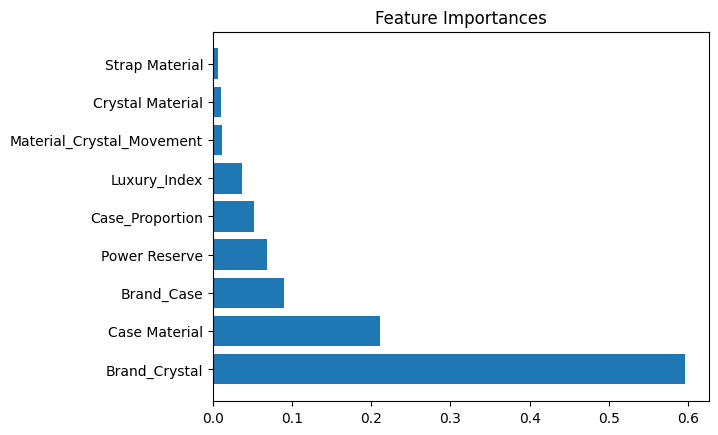

In [57]:
plt.barh(importances['feature'], importances['importance'])
plt.title("Feature Importances")
plt.show()

## Fine-Tune CatBoost Model
Perform hyperparameter tuning to find the best parameters for the CatBoost model.

In [58]:
scorer = make_scorer(r2_score)

cb_model =CatBoostRegressor(random_state=42, loss_function='RMSE', verbose=False, cat_features=cat_columns)

param_grid = {
    'iterations': [200, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'bagging_temperature': [0.1, 0.3, 0.5]
}

grid_search = GridSearchCV(estimator=cb_model, param_grid=param_grid,
                           scoring=scorer, cv=3, n_jobs=-1, verbose=False)

grid_search.fit(X_train, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best R2 Score: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f'R2 Score: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')

Best Parameters: {'bagging_temperature': 0.1, 'depth': 4, 'iterations': 500, 'learning_rate': 0.05}
Best R2 Score: 0.8999
R2 Score: 0.8969
RMSE: 2280.2140
MAE: 1728.8769


## Evaluate CatBoost Model
Evaluate the model's performance using the best parameters obtained from fine-tuning.

In [ ]:
best_cb_model = CatBoostRegressor(iterations=500, depth=4, learning_rate=0.05, bagging_temperature=0.1, cat_features=cat_columns, verbose=False)

best_cb_model.fit(X_train, y_train)

y_pred = best_cb_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f'R2 Score: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')

R2 Score: 0.8931
RMSE: 2321.9042
MAE: 1773.3985


In [60]:
import joblib

joblib.dump(best_cb_model, 'models/copy catboost_model.pkl')

['models/copy catboost_model.pkl']

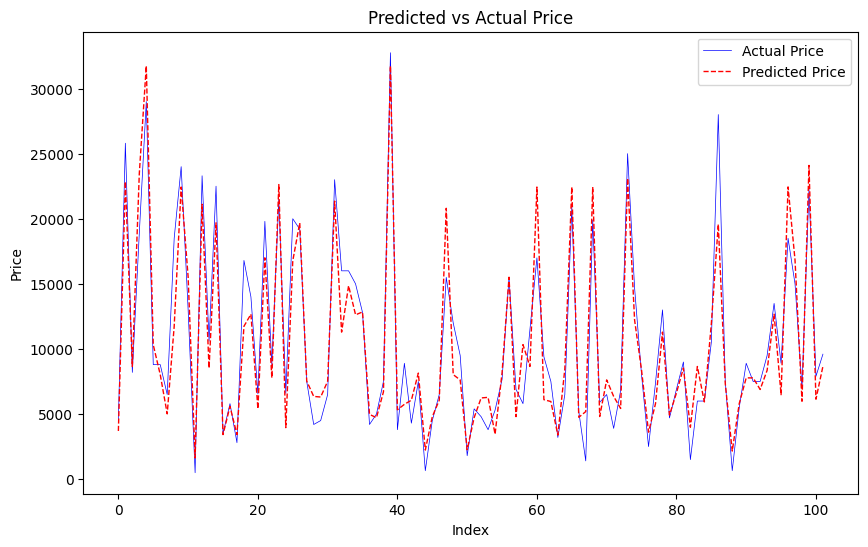

In [62]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label='Actual Price', color='blue', lw=0.5)
plt.plot(range(len(y_pred)), y_pred, label='Predicted Price', color='red', lw=1, linestyle='--')
plt.title('Predicted vs Actual Price')
plt.xlabel('Index')
plt.ylabel('Price')
plt.legend()
plt.show()